### 17장. 회귀 모델 개요 및 데이터 준비

분류 모델이 선거일 투표율이 높은 위험 읍면동을 사전에 식별하는 목적이었다면, 
회귀 모델은 읍면동별 선거일 투표 수요를 수치로 추정하는 목적이다. 
예측된 선거일투표수를 바탕으로 여유분을 반영하면, 일괄 50% 배정 방식과 
비교 가능한 데이터 기반 배정 참고 기준을 만들 수 있다.

타겟 변수는 선거일투표수로 설정했다. 선거일투표수는 평균 3,803표, 
표준편차 3,648표로 변동 폭이 크고, 최대값이 36,751표까지 나타나 
오른쪽으로 긴 분포를 보인다. 대규모 읍면동에 모델이 과도하게 끌려가는 것을 
방지하기 위해 np.log1p() 로그 변환을 적용했다.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# 데이터 불러오기 및 파생변수 재생성 (03_modeling과 동일 기준)
df = pd.read_excel('output/cleaned_vote_data.xlsx')

mean_val = df['선거일투표율'].mean()
std_val = df['선거일투표율'].std()
threshold = mean_val + std_val

df['위험투표소'] = (df['선거일투표율'] > threshold).astype(int)
df['규모_그룹'] = pd.qcut(df['총선거인수'], q=3, labels=['소규모', '중규모', '대규모'])

# 피처/타겟 분리 (타겟이 분류→회귀로 변경)
features = ['총선거인수', '사전투표율', '시도', '규모_그룹']
target = '선거일투표수'

X = df[features]
y = df[target]

# 범주형 인코딩
X_encoded = pd.get_dummies(X, columns=['시도', '규모_그룹'], drop_first=True)

# 분포가 오른쪽으로 치우쳐 있어 로그 변환 적용
y_log = np.log1p(y)

# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)

# 모델 정의
xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    objective="reg:squarederror",
    random_state=42
)

print("회귀 모델 세팅 완료")
print(f"train: {X_train.shape}, test: {X_test.shape}")

### 18장. 회귀 모델 학습 및 성능 평가

**평가 지표**
회귀 모델은 분류와 달리 예측값과 실제값의 차이를 수치로 평가한다.

- MAE (평균 절대 오차): 예측이 평균적으로 얼마나 틀렸는지
- RMSE (평균 제곱근 오차): 큰 오차에 더 민감한 지표
- R² (결정계수): 모델이 분산을 얼마나 설명하는지 (1에 가까울수록 좋음)

**시각화 해석**
대부분의 예측값이 실제값과 근접한 대각선 부근에 분포하며,
오차 분포도 0을 중심으로 집중되어 있다.
다만 대규모 읍면동에서 일부 과소 예측이 나타나는데,
이는 피처 수 부족에서 오는 한계로 판단된다.


In [ ]:
# 6. 모델 학습
xgb_reg.fit(X_train, y_train)

# 7. 예측
y_pred_log = xgb_reg.predict(X_test)

# 로그 스케일 예측값을 실제 투표수 단위로 복원
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# 투표수는 음수가 될 수 없으므로 0 미만 값은 보정
y_pred = np.clip(y_pred, 0, None)

# 8. 성능 평가
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"MAE  : {mae:.1f} 표")
print(f"RMSE : {rmse:.1f} 표")
print(f"R²   : {r2:.4f}")

# 성능 평가 출력 후 이거 추가
print(f"\n선관위 일괄 배정 대비 평균 오차: {mae/df['선거일투표수'].mean()*100:.1f}%")

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_actual,
    y=y_pred,
    alpha=0.6
)

max_value = max(float(y_actual.max()), float(y_pred.max()))

plt.plot(
    [0, max_value],
    [0, max_value],
    color="red",
    linestyle="--",
    label="실제값 = 예측값"
)

plt.title("실제 선거일투표수 vs 예측 선거일투표수")
plt.xlabel("실제 선거일투표수")
plt.ylabel("예측 선거일투표수")
plt.legend()
plt.tight_layout()
plt.show()

residual = y_actual - y_pred

plt.figure(figsize=(7, 5))

sns.histplot(residual, bins=40, kde=True)

plt.axvline(0, color="red", linestyle="--")
plt.axvline(
    residual.mean(),
    color="black",
    linestyle=":",
    label=f"평균 오차: {residual.mean():.1f}표"
)

plt.title("예측 오차 분포")
plt.xlabel("오차 = 실제값 - 예측값")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()

### 19장. 데이터 기반 용지 배정 시뮬레이션

회귀 모델의 예측값에 통계적 버퍼를 더해 읍면동별 배정량을 산출하고,
일괄 50% 배정 방식과 비교했다.

**시뮬레이션 결과**

예측+1.65σ 방식 기준, 총 배정량은 일괄 50% 방식 대비 15.2% 적었고,
부족 발생 읍면동은 33개(4.7%)로 나타났다.

일괄 50% 방식은 부족 위험을 낮추는 데는 효과적이지만,
모든 읍면동에 동일한 기준을 적용하기 때문에 지역별 수요 차이를 세밀하게 반영하기 어렵다.

반면 모델 기반 방식은 읍면동별 예측 수요에 따라 배정량을 차등 산정할 수 있다.
따라서 부족 위험과 총 배정량 사이의 균형을 수치로 비교하는 참고 기준으로 활용할 수 있다.

**한계**

테스트 데이터 기준 일괄 50% 방식의 부족 읍면동이 1개로 낮게 나타난 점은
표본 분할의 영향이 있을 수 있다. 또한 실제 2026년 선거에서는 보도 기준 50곳 이상의 부족 사례가 확인되었으므로,
본 시뮬레이션 결과는 절대적인 결론이 아니라 배정 방식 비교를 위한 참고 결과로 해석해야 한다.

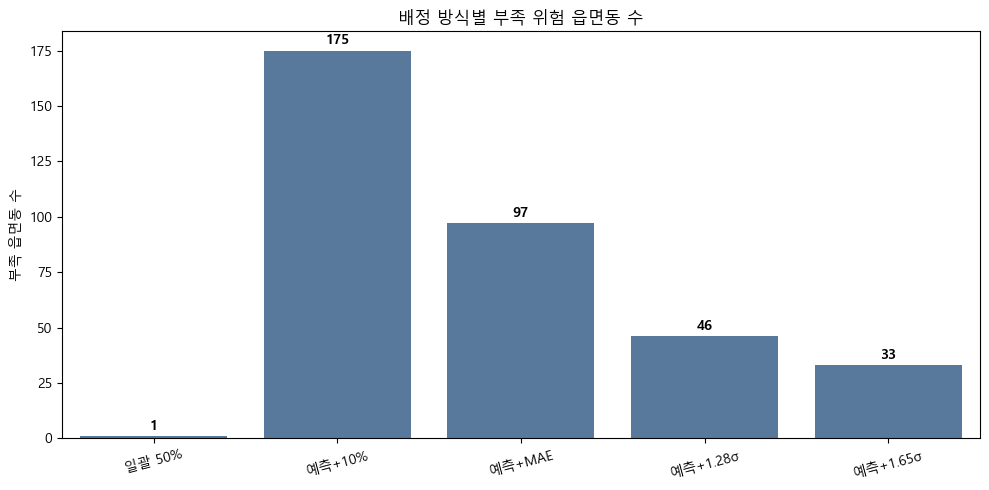

,배정 방식,부족 읍면동 수,부족률(%),총 배정량,50% 대비 증감,50% 대비 증감률(%)
0,선관위_50퍼센트_배정량,1,0.14,4240544.0,0.0,0.00
1,모델_10퍼센트_버퍼,175,24.93,2970569.5,-1269974.5,-29.95
2,모델_MAE_버퍼,97,13.82,3009938.0,-1230606.0,-29.02
3,모델_1.28표준편차_버퍼,46,6.55,3394155.0,-846389.0,-19.96
4,모델_1.65표준편차_버퍼,33,4.70,3594659.5,-645884.5,-15.23


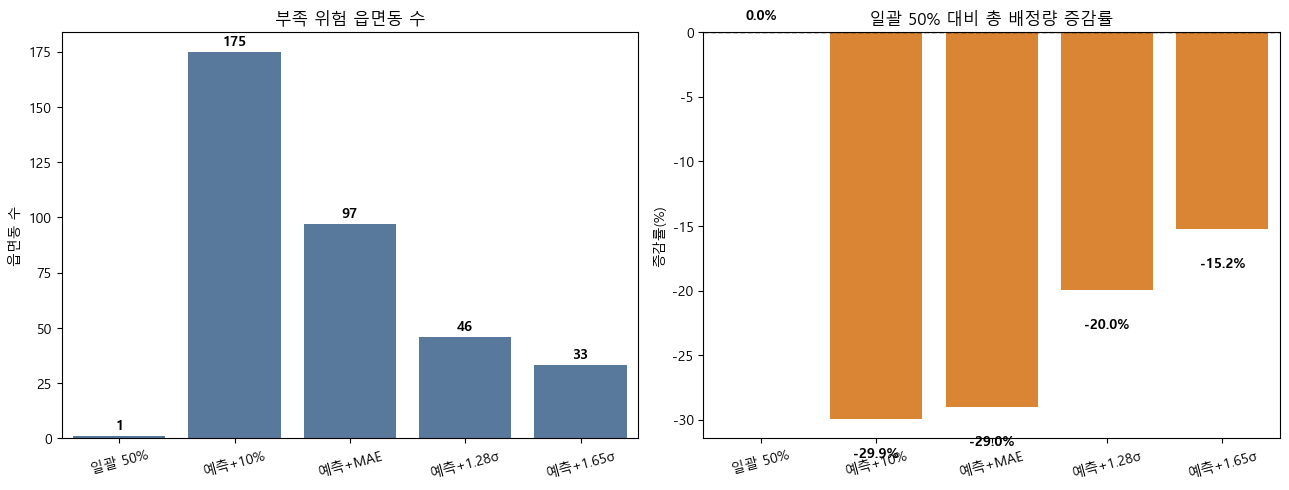

In [17]:
# 9. 시뮬레이션용 데이터 준비
sim_df = df.loc[X_test.index].copy()

sim_df["예측_선거일투표수"] = y_pred
sim_df["실제_선거일투표수"] = sim_df["선거일투표수"]

# 테스트셋 기준 오차
residual = y_actual - y_pred
mae = mean_absolute_error(y_actual, y_pred)
error_std = residual.std()

# 배정 방식 비교
sim_df["선관위_50퍼센트_배정량"] = sim_df["총선거인수"] * 0.5
sim_df["모델_10퍼센트_버퍼"] = sim_df["예측_선거일투표수"] * 1.10
sim_df["모델_MAE_버퍼"] = sim_df["예측_선거일투표수"] + mae
sim_df["모델_1.28표준편차_버퍼"] = sim_df["예측_선거일투표수"] + 1.28 * error_std
sim_df["모델_1.65표준편차_버퍼"] = sim_df["예측_선거일투표수"] + 1.65 * error_std

allocation_cols = [
    "선관위_50퍼센트_배정량",
    "모델_10퍼센트_버퍼",
    "모델_MAE_버퍼",
    "모델_1.28표준편차_버퍼",
    "모델_1.65표준편차_버퍼"
]

summary = []

base_shortage = (
    sim_df["실제_선거일투표수"] > sim_df["선관위_50퍼센트_배정량"]
).sum()

base_total = sim_df["선관위_50퍼센트_배정량"].sum()

for col in allocation_cols:
    shortage = (sim_df["실제_선거일투표수"] > sim_df[col]).sum()
    total_allocation = sim_df[col].sum()
    
    summary.append({
        "배정 방식": col,
        "부족 읍면동 수": shortage,
        "부족률(%)": shortage / len(sim_df) * 100,
        "총 배정량": total_allocation,
        "50% 대비 증감": total_allocation - base_total,
        "50% 대비 증감률(%)": (total_allocation / base_total - 1) * 100
    })

summary_df = pd.DataFrame(summary)
summary_df

plt.figure(figsize=(10, 5))

plot_df = summary_df.copy()
plot_df["배정 방식"] = plot_df["배정 방식"].replace({
    "선관위_50퍼센트_배정량": "일괄 50%",
    "모델_10퍼센트_버퍼": "예측+10%",
    "모델_MAE_버퍼": "예측+MAE",
    "모델_1.28표준편차_버퍼": "예측+1.28σ",
    "모델_1.65표준편차_버퍼": "예측+1.65σ"
})

sns.barplot(
    data=plot_df,
    x="배정 방식",
    y="부족 읍면동 수",
    color="#4C78A8"
)

plt.title("배정 방식별 부족 위험 읍면동 수")
plt.xlabel("")
plt.ylabel("부족 읍면동 수")
plt.xticks(rotation=15)

for i, v in enumerate(plot_df["부족 읍면동 수"]):
    plt.text(i, v + 3, f"{v}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()
display(summary_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df = summary_df.copy()
plot_df["배정 방식"] = plot_df["배정 방식"].replace({
    "선관위_50퍼센트_배정량": "일괄 50%",
    "모델_10퍼센트_버퍼": "예측+10%",
    "모델_MAE_버퍼": "예측+MAE",
    "모델_1.28표준편차_버퍼": "예측+1.28σ",
    "모델_1.65표준편차_버퍼": "예측+1.65σ"
})

sns.barplot(
    data=plot_df,
    x="배정 방식",
    y="부족 읍면동 수",
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title("부족 위험 읍면동 수")
axes[0].set_xlabel("")
axes[0].set_ylabel("읍면동 수")
axes[0].tick_params(axis="x", rotation=15)

for i, v in enumerate(plot_df["부족 읍면동 수"]):
    axes[0].text(i, v + 3, f"{int(v)}", ha="center", fontweight="bold")


sns.barplot(
    data=plot_df,
    x="배정 방식",
    y="50% 대비 증감률(%)",
    color="#F58518",
    ax=axes[1]
)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("일괄 50% 대비 총 배정량 증감률")
axes[1].set_xlabel("")
axes[1].set_ylabel("증감률(%)")
axes[1].tick_params(axis="x", rotation=15)

for i, v in enumerate(plot_df["50% 대비 증감률(%)"]):
    axes[1].text(
        i,
        v + 1 if v >= 0 else v - 3,
        f"{v:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()



### 20장. 종합 시뮬레이션 결과

본 프로젝트는 과거 지방선거 데이터를 활용해 읍면동별 선거일 투표 수요 차이를 분석하고,
일괄 배정 방식의 한계를 데이터 관점에서 검토했다.

분류 모델은 선거일 투표율이 높은 위험 읍면동을 사전에 스크리닝하는 데 활용했다.
임계값 0.3 기준, 실제 위험 읍면동 107개 중 81개를 식별해 75.7%의 식별률을 보였다.

회귀 모델은 읍면동별 선거일 투표수를 예측하는 데 활용했다.
테스트 데이터 기준 MAE는 약 441표, R²는 0.954로 나타났으며,
예측값은 배정량 산정의 참고 기준으로 사용할 수 있는 수준의 설명력을 보였다.

배정량 시뮬레이션에서는 예측값에 통계적 버퍼를 적용해 일괄 50% 방식과 비교했다.
예측+1.65σ 방식은 일괄 50% 방식 대비 총 배정량을 15.2% 줄이면서,
부족 위험 읍면동을 33개(4.7%) 수준으로 낮췄다.

단, 테스트 데이터 기준 일괄 50% 방식의 부족이 1개로 낮게 나타난 점은
표본 분할의 영향이 있을 수 있으므로,
절대적 비교보다는 배정 방식별 trade-off를 확인하는 참고 결과로 해석해야 한다.

종합하면, 일괄 50% 방식은 부족 위험을 낮추는 데 효과적이지만,
지역별 선거일 투표 수요 편차를 세밀하게 반영하기는 어렵다.

반면 데이터 기반 방식은 위험 지역 식별과 수요 예측을 통해
부족 위험과 배정량 사이의 균형을 사전에 검토할 수 있는 참고 기준을 제공한다.

따라서 과거 투표 데이터를 활용했다면,
2026년 6.3 지방선거와 같은 용지 부족 위험 지역을
사전에 더 정교하게 식별하는 데 도움이 되었을 가능성이 있다.